<a href="https://colab.research.google.com/github/sgl13/Deep_Learning/blob/main/CNN_execution_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A **Convolutional Neural Network (CNN)** is a specialized type of deep learning model designed primarily to process and analyze structured grid data, most commonly visual data like images and videos.

Unlike traditional neural networks, CNNs automatically learn to recognize patterns and features (such as edges, textures, and shapes) by applying mathematical filters (convolutions) across the input.

**Convolutional layers:**

Extract features from the image using filters.

**Pooling layers:**

Reduce the spatial dimensions (downsampling) to make computation more efficient while retaining essential information.

**Fully connected layers:**

Flatten the processed data into a single vector to classify the image or make a final prediction.

1. How an image enters in to CNN
2. How an image converted in to tensors
3. How conv2d extracts features
4. How ReLU introduces non-linearity
5. How maxpool reduces dimensions
6. How flatten converts feature maps in to a vector
7. How linear layer performs classificastion
8. How the model produces the classification probabilites
9. How to train the CNN
10. How to test the model with new imager
11. How to interpret the predictions

step1:- Import the libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms  #Images and datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from PIL import Image  #TO PROCESS THE IMAGE USE PIL
import numpy as np


Q)Why we are using pytorch instead of directly giving image to mathematical operations on the image?


Beacuse CNN needs to perform thousands and millions of mathematical operations on the image

so the pytorch provides
1. tensors
2. CNN layers
3. automatic differentiation
4. GPU accelrator
5. Optimizers
6. training utilities


*use the MNIST handwritten-digit dataset for out first implementation*

MNIST contains the images like  0, 1, 2, 3,..........9

each image is 28 * 28  and these are grayscale

height is = 28

width = 28

channel =  1



**Load the dataset**

In [2]:
transform = transforms.ToTensor()  # intiate the model to transform data to tensors

train_dataset = datasets.MNIST(
    root="./data",
    train = True,
    download = True,
    transform = transform
)

test_dataset = datasets.MNIST(
    root = "./data",
    train = False,
    download = True,
    transform = transform

)

**what happens in above step**?

ToTensor() converts the images into pytorch

ex: each image size is

28 * 28 pixels

after conversion

1 * 28 * 28

1 represents the greysacle channel


why we need to coinvert an image to tensors --> bcz CNN doesnt understand the image

    [0,0,255]
    [0,128,255]
    [255,255,255]


After conversion values may lookes approxematly like this

      [0.0,0.0,1.0]
      [0.0,0.5,1.0]
      [1.0,1.0,1.0]
so the CNN learns the patterns from the numbers


**Create a Data Loader**

In [3]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

so instead of sending 60,000 images to the network at once we send

64 images --> CNN --> predictions --> loss --> update weights

**display the actual images**

Image shape torch.Size([1, 28, 28])
label 5


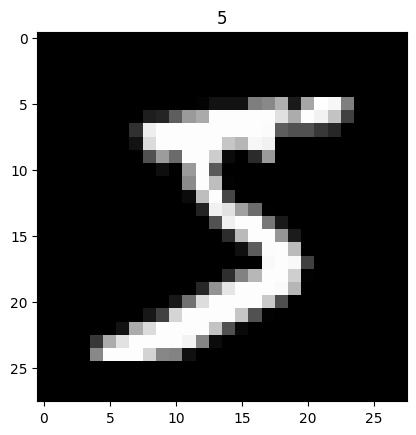

In [4]:
image, label = train_dataset[0]
print("Image shape",image.shape)
print("label",label)

plt.imshow(image.squeeze(),cmap="gray")
plt.title(label)
plt.show()


If i give a 28 X 28 gray scale image to a cnn model , is input shape simply 28 X 28?

ans)  NO

Batch * channel * height * width

64 X 1 X 28 X 28


**build the CNN model**

In [5]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()
    self.conv1 = nn.Conv2d(
        in_channels = 1,
        out_channels = 16,
        kernel_size = 3,
        padding = 1
    )
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(
        kernel_size=2,
        stride=2
    )

    self.conv2 = nn.Conv2d(
        in_channels = 16,
        out_channels = 32,
        kernel_size = 3,
        padding = 1
    )

    self.fc1 = nn.Linear(
       32 * 7 * 7,
       128
    )

    self.fc2 = nn.Linear(
        128,
        10
    )

  def forward(self,x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = self.relu(x)

    x = self.pool(x)

    x = x.view(x.size(0),-1)

    x = self.fc1(x)
    x = self.relu(x)

    x = self.fc2(x)

    return x

In [6]:
#1 * 28 * 28   --> conv 1 -->   1 * 14 * 14  --> 16 * 14 * 14 --> conv 2 --> 32 * 14 * 14 --> 32 * 7 * 7
#128 0out put values
#in fc2 the 128 output values is converted to 10 output values
# stride to control the number of pixels (or steps)

#Input image --> 1 X 28 X 28 ---> conv2D --> Relu --> maxpooling --> 16 X 14 X 14 --> cov2d -->Relu --> maxpooling --> 32 X 7 X 7 --> flatten --> 1568 --> fully connected layer --> 128 --> 10 outputs--> digit prediction

**Instantiate the model**

In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNN().to(device)
print(model)
print(device)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
cuda


**Loss function**

In [8]:
criterion = nn.CrossEntropyLoss()

**optimizer**

In [9]:
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

#What adam will do?
#model contains millions of possible learning parameters in larger CNN models

#the optimizer adjust the weights based on gradient



**Training of CNN's**

In [10]:
epochs = 5
for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(
      f"epoch  [{epoch+1}/{epochs}],"
      f"loss {running_loss/len(train_loader):.4f}"
  )


epoch  [1/5],loss 0.2409
epoch  [2/5],loss 0.0624
epoch  [3/5],loss 0.0443
epoch  [4/5],loss 0.0339
epoch  [5/5],loss 0.0268


**evaluate the model**

In [11]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.03%


**sending an image throught the model**

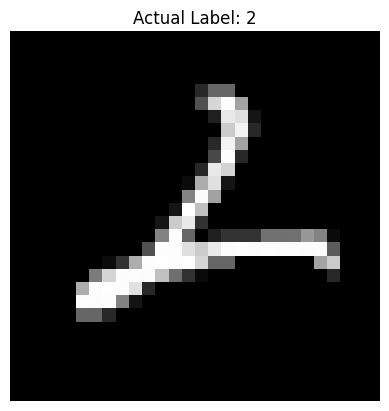

In [12]:
image, true_label = test_dataset[43]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {true_label}")
plt.axis("off")
plt.show()

In [13]:
model.eval()

input_image = image.unsqueeze(0).to(device)

with torch.no_grad():

    output = model(input_image)

    predicted_class = torch.argmax(output, dim=1).item()

print("Actual:", true_label)
print("Predicted:", predicted_class)

Actual: 2
Predicted: 2


In [14]:
#see th predictions

In [15]:
probabilities = torch.softmax(output, dim=1)  #converts the output in to probabilities

print(probabilities)


tensor([[6.0540e-07, 6.2062e-04, 9.9871e-01, 2.1117e-07, 6.3894e-04, 2.4727e-07,
         2.5102e-05, 8.3954e-07, 3.8997e-07, 2.1663e-09]], device='cuda:0')


In [16]:
probs = probabilities.cpu().numpy()[0]

for digit, prob in enumerate(probs):
    print(f"Digit {digit}: {prob*100:.2f}%")

Digit 0: 0.00%
Digit 1: 0.06%
Digit 2: 99.87%
Digit 3: 0.00%
Digit 4: 0.06%
Digit 5: 0.00%
Digit 6: 0.00%
Digit 7: 0.00%
Digit 8: 0.00%
Digit 9: 0.00%


Visualize Prediction Confidence

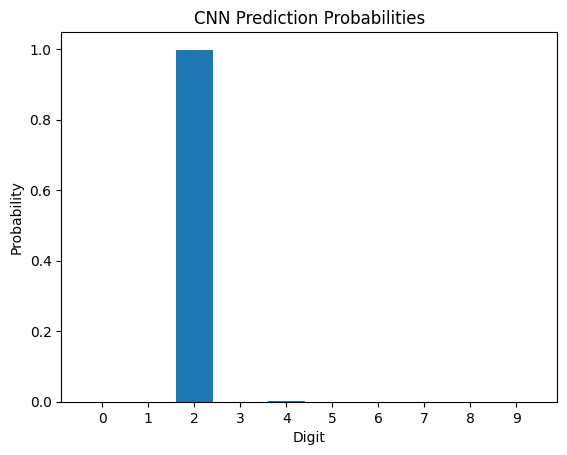

In [17]:
plt.bar(range(10), probs)

plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title("CNN Prediction Probabilities")

plt.show()

In [18]:
#Q)Why we are taking 10 outputs?
#a)MNIST ==>inbuilt library for handwritten numbers --> 0, to  9  --> the count is


#working achetecture of CNN model

#Input (image)  --> Tensors(Transforms)  --> convolution layers (Sends a kernal to reduce the shape of image)--> (ReLU) -->pooling --> Flatten --> fully connected layers --> outputlayer (softmax)
#pooling is downsampling process . it reduces height and width of feature map while mapping important infomation



#Q)How ReLU introduces non-linearity?
#ReLu --> rectified Linear unit
#Relu = max(0,x)
#if the input is negative ReLU converts in to 0. if the the input is +ve ReLU keep it unchanged.


#Q)Why do we need ReLU in CNN?
#a) Image  --> convolution --> feature map
#convolution -->   z = w,x1 +w2x2 +.....+wnxn

#if the result is givnen --> -5 2 -1 9 -3 4
#relu convert the above -->  0 2  0 9  0 4